In [5]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.decomposition import PCA
import matplotlib.transforms as transforms
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import f
import pickle
import seaborn as sns
from sklearn.metrics import *

# Load the data

In [6]:
data = pd.read_csv(r'M:\ML_scripts\github_files\cm60-full-compiled-data.csv').drop(columns=['Unnamed: 0'])

train = data[data['Set'] == 'train']
test = data[data['Set'] == 'test']

train_smi = train['Structure']
test_smi = test['Structure']

train_clf = train['Class']
test_clf = test['Class']

In [7]:
data

,Structure,Class,nBase,VE1_A,VR2_A,VR3_A,nAromAtom,ATS3dv,ATS6dv,AATS0dv,...,fr_piperdine,fr_pyridine,Set,Pred,Bin Pred,PC1,PC2,MaxSim,SimPartner,ConfusionLabel
0,C[C@@H]([C@H]1NC(=O)C[N@](CCOc2c(ccc(c2)-c3[n@...,0,-0.552546,-0.879920,0.115553,0.697076,1.441218,0.156034,-0.087225,1.017394,...,-0.542024,-0.408038,train,0.100271,0,0.470268,0.301628,0.747253,C[C@@H]([C@H]1NC(=O)C[N@](CCOc2c(ccc(c2)-c3[n@...,TN
1,C[C@H]1CC(=O)N[C@@H](C(=O)[N@@]2[C@H](C(=O)N[C...,0,-0.552546,0.279817,-0.335060,-0.521031,-1.853564,-0.588005,0.058160,-0.563241,...,-0.542024,-0.408038,train,0.077746,0,1.514908,-0.762856,0.747253,C[C@H]1CC(=O)N[C@@H](C(=O)[N@@]2[C@H](C(=O)N[C...,TN
2,CCOCCC(=O)[N@@]1Cc2ccc(cc2)C(=O)N[C@@H](C(=O)N...,0,-0.552546,0.918665,-0.314314,-0.286790,-1.093230,-0.692309,-0.363925,-1.577231,...,-0.542024,-0.408038,train,0.087613,0,2.678616,-0.427997,0.782051,C[C@H]1NC(=O)[C@@H](NC(=O)[C@H](NC(=O)c2ccc(cc...,TN
3,Cc1nc2[n@](nc(c2C(=O)[N@@]3CCCNC(=O)[C@H](NC(=...,0,-0.552546,-1.974816,0.755985,0.916194,-1.853564,-1.033038,-1.935021,-0.743633,...,-0.542024,-0.408038,train,0.132848,0,1.040618,0.210584,0.581081,C[C@H]1NC(=O)CCC[N@@](CCCNC(=O)[C@H](NC1=O)[C@...,TN
4,C[C@@H]([C@H]1NC(=O)Cc2cc(ccc2)OCC[n@@]3nnc(c3...,0,-0.552546,1.550298,-0.406843,-0.688043,0.173994,-0.553237,0.166027,-0.811255,...,-0.542024,-0.408038,train,0.262584,0,1.465102,1.400536,0.795699,C[C@@H]([C@H]1NC(=O)Cc2cc(ccc2)OCC[n@@]3nnc(c3...,TN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031,CCOc1ncccc1C(=O)N[C@@H]2C(=O)N[C@@H](C(=O)N[C@...,0,-0.552546,1.399582,-0.405731,-0.681402,-1.093230,0.441133,0.222305,-0.172432,...,-0.542024,2.407107,test,0.179344,0,3.322937,-2.559185,0.776471,C[C@H]1NC(=O)[C@H](NC(=O)[C@H](CCCNC(=O)C[N@@]...,TN
2032,CC[C@@H]1NC(=O)[C@H](NC(=O)c2nc(sc2)[C@@H](NC(...,0,-0.552546,0.900340,-0.264200,0.208209,0.173994,0.853715,1.247816,-0.606875,...,-0.542024,2.407107,test,0.181708,0,2.333871,-1.873994,0.890110,CC[C@@H]1NC(=O)[C@H](NC(=O)c2nc(sc2)[C@@H](NC(...,TN
2033,CC[N@]1CC(=O)N[C@H]2C[N@](CC[C@@H]2OCc3cccc(c3...,0,-0.552546,0.563486,-0.377354,-0.771809,0.427439,-0.588005,-0.518690,-0.156259,...,1.681024,-0.408038,test,0.769586,1,-4.522319,-1.407205,0.783784,CC[N@]1CC(=O)N[C@H]2C[N@](CC[C@@H]2OCc3cccc(c3...,FP
2034,C[C@H]1NC(=O)CCC[N@@](CCCNC(=O)[C@H](NC1=O)[C@...,0,-0.552546,-1.746718,-0.065833,-0.246202,-1.600119,-1.561514,-2.117925,-0.718508,...,-0.542024,2.407107,test,0.286282,0,1.120642,0.182455,0.712121,C[C@H]1NC(=O)CCC[N@@](CCCNC(=O)[C@H](NC1=O)[C@...,TN


# Load model descriptor

In [8]:
with open(r'M:\ML_scripts\MODEL DATA\colistin models_data\col_2.pkl', 'rb') as file:
    model = pickle.load(file)

predictor = model.predictor
descriptor = model.descriptor

# Generate descriptors (for CM-60: ECFP and UPC)

In [9]:
train_fp = []
test_fp = []

for x in train_smi:
    desc = descriptor.calculate_from_smi(x)
    train_fp.append((desc))

for x in test_smi:
    desc = descriptor.calculate_from_smi(x)
    test_fp.append((desc))

# Fit the PCA

In [10]:
pca = PCA(n_components=2)

train_pca = pca.fit_transform(train_fp)
test_pca = pca.transform(test_fp)

# Finding the AD

In [11]:
eigenvalues = pca.explained_variance_

T2_train = np.sum((train_pca ** 2) / eigenvalues, axis=1)

n = len(train_fp)
p = 2
alpha = 0.01

F_val = f.ppf(1 - alpha, p, n - p)
T2_threshold = (p * (n-1) * F_val) / (n - p)

print(f'Threshold at 95% confidence level: {T2_threshold:.4f}')

T2_test = np.sum((test_pca ** 2) / eigenvalues, axis=1)

t2_values = []

for i, t2 in enumerate(T2_train):
    if t2 <= T2_threshold:
        print(f'Train point {i} is inside the AD space with T2 value: {t2:.4f}')
    else:
        print(f'Train point {i} is outside the AD space with T2 value: {t2:.4f}')

    t2_values.append(t2)


for i, t2 in enumerate(T2_test):
    if t2 <= T2_threshold:
        print(f'Test point {i} is inside the AD space with T2 value: {t2:.4f}')
    else:
        print(f'Test point {i} is outside the AD space with T2 value: {t2:.4f}')

    t2_values.append(t2)

Threshold at 95% confidence level: 9.2687
Train point 0 is inside the AD space with T2 value: 0.2009
Train point 1 is inside the AD space with T2 value: 0.1949
Train point 2 is inside the AD space with T2 value: 0.2707
Train point 3 is inside the AD space with T2 value: 1.9835
Train point 4 is inside the AD space with T2 value: 0.0764
Train point 5 is inside the AD space with T2 value: 4.2559
Train point 6 is inside the AD space with T2 value: 0.0705
Train point 7 is inside the AD space with T2 value: 0.6347
Train point 8 is inside the AD space with T2 value: 0.8388
Train point 9 is inside the AD space with T2 value: 0.1239
Train point 10 is inside the AD space with T2 value: 0.2270
Train point 11 is inside the AD space with T2 value: 0.6801
Train point 12 is inside the AD space with T2 value: 6.2137
Train point 13 is inside the AD space with T2 value: 1.0333
Train point 14 is inside the AD space with T2 value: 0.0480
Train point 15 is inside the AD space with T2 value: 0.9380
Train po

In [12]:
data['t2_thresh'] = t2_values

# Plotting the AD

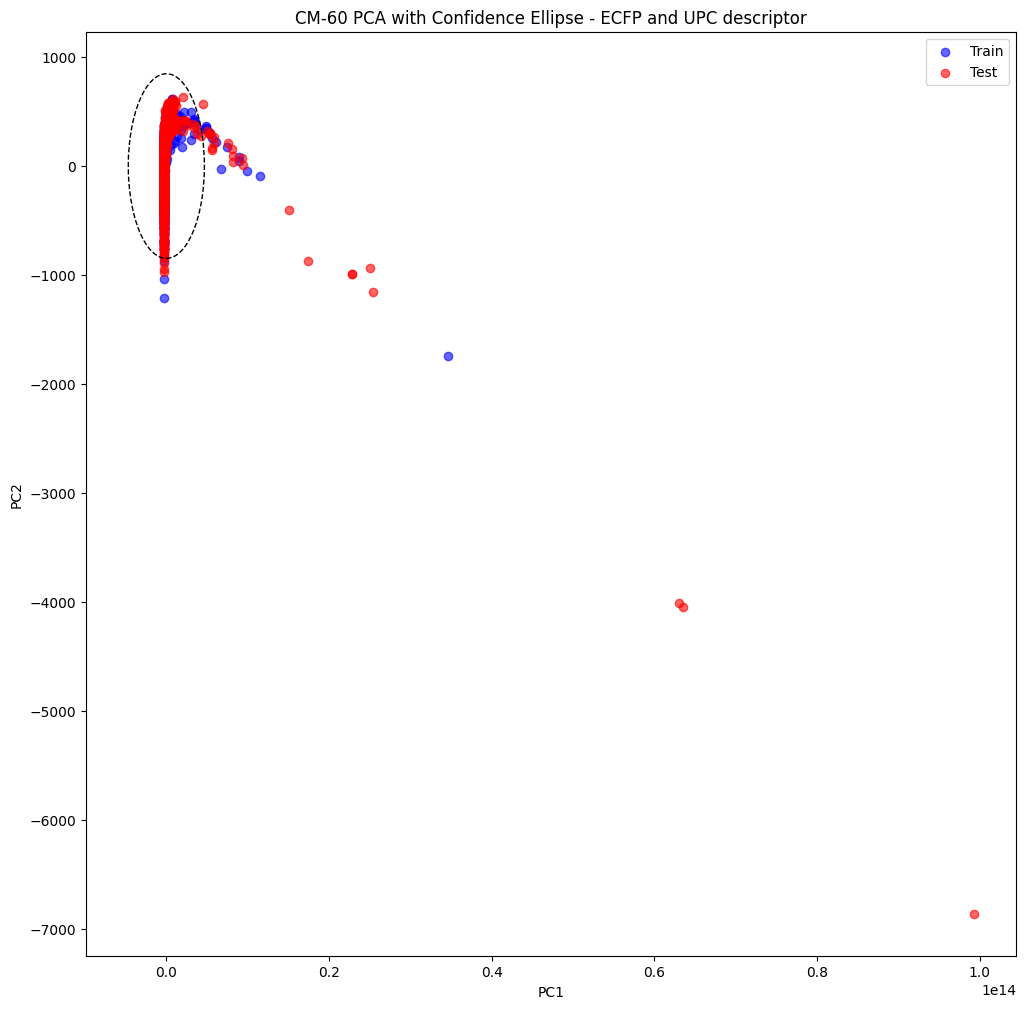

In [22]:
plt.figure(figsize=(12, 12))

plt.scatter(train_pca[:, 0], train_pca[:, 1], label='Train', alpha=0.6, color='blue')
plt.scatter(test_pca[:, 0], test_pca[:, 1], label='Test', alpha=0.6, color='red')


def plot_confidence_ellipse(mean, cov, ax, threshold, **kwargs):

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    width, height = 2 * np.sqrt(vals * threshold)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=theta, **kwargs)
    ax.add_patch(ellipse)

ax = plt.gca()
mean = np.mean(train_pca[:, :2], axis=0)
cov = np.cov(train_pca[:, :2].T)

plot_confidence_ellipse(mean, cov, ax, T2_threshold, edgecolor='black', facecolor='none', linestyle='--')

plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('CM-60 PCA with Confidence Ellipse - ECFP and UPC descriptor')
plt.show()

# Removing the outliers

In [14]:
ad_data = data[data['t2_thresh'] < T2_threshold]

ad_train = ad_data[ad_data['Set'] == 'train']
ad_test = ad_data[ad_data['Set'] == 'test']

In [15]:
# ad_train.to_csv('./AD-CM-60_training_set.csv')
# ad_test.to_csv('./AD-CM-60_testing_set.csv')

Text(0.5, 1.0, 'CM-60 PCA with Confidence Ellipse - ECFP and UPC descriptor (outliers removed)')

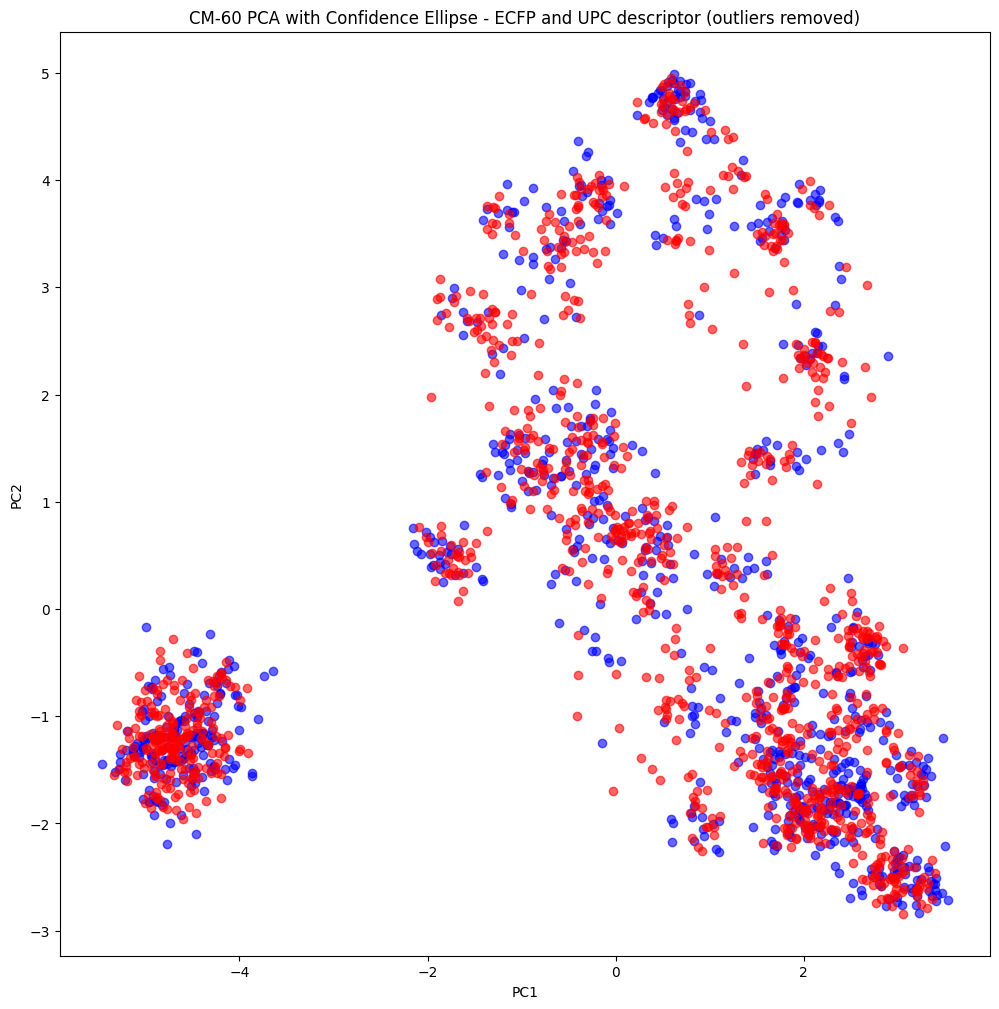

In [23]:
plt.figure(figsize=(12, 12))

plt.scatter(ad_train['PC1'], ad_train['PC2'], label='Train', alpha=0.6, color='blue')
plt.scatter(ad_test['PC1'], ad_test['PC2'], label='Test', alpha=0.6, color='red');
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('CM-60 PCA with Confidence Ellipse - ECFP and UPC descriptor (outliers removed)')